# CS729 Question 5: Comparing SGD, DP-SGD, FTRL, and DP-FTRL

In this notebook, we compare the following optimizers on the MNIST dataset using a feed-forward neural network:

1. **SGD** (non-private)
2. **FTRL** (non-private)
3. **DP-SGD**
4. **DP-FTRL**

For the private optimizers, we evaluate two target privacy budgets:

$$
\epsilon \in \{1, 10\}, \qquad \delta = 10^{-5}
$$

We report the following plots required in Question 5:

1. **Number of Iterations (Epoch × Batches) vs Training Loss**
2. **$\epsilon$ spent vs Epochs**
3. **Target Epsilon vs Test Accuracy**

As required in the assignment, the privacy accounting setup is kept uniform with the DP-FTRL implementation by using the **RDP accountant** for DP-SGD as well. For DP-FTRL, we use the privacy computation routine provided in the public DP-FTRL implementation. :contentReference[oaicite:0]{index=0}

We also compare the private methods against their non-private counterparts:
- DP-SGD vs SGD
- DP-FTRL vs FTRL

**Implementation note.**  
For a fair comparison, the non-private baselines are trained **without privacy noise** and **without DP-style gradient clipping**. Gradient clipping is only used inside the private methods where it is part of the differential privacy mechanism.

In [1]:
!pip install -q opacus absl-py
!wget -q https://raw.githubusercontent.com/google-research/DP-FTRL/main/optimizers.py -O dpftrl_optimizers.py
!wget -q https://raw.githubusercontent.com/google-research/DP-FTRL/main/ftrl_noise.py -O dpftrl_noise.py
!wget -q https://raw.githubusercontent.com/google-research/DP-FTRL/main/privacy.py -O dpftrl_privacy.py

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 254.4/254.4 kB 6.2 MB/s eta 0:00:00a 0:00:01


In [2]:
import math
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from dataclasses import dataclass
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from torch.func import functional_call, grad, vmap

from opacus import PrivacyEngine
from opacus.accountants.utils import get_noise_multiplier

from dpftrl_optimizers import FTRLOptimizer
from dpftrl_noise import CummuNoiseEffTorch
from dpftrl_privacy import compute_epsilon_tree

warnings.filterwarnings("ignore")

## Experimental Setup

To keep the notebook manageable and directly runnable, we use:

- MNIST
- a simple feed-forward neural network
- batch size 250 (so that 60,000 training samples divide exactly into full batches)
- 10 epochs
- target privacy budgets $(\epsilon \in \{1, 10\})$
- $(\delta = 10^{-5})$

For DP-FTRL, we use:
- clipping norm $C = 1.0$
- tree-aggregated Gaussian noise
- restart every epoch
- tree completion enabled

Restarting every epoch keeps the implementation clean and makes the privacy accounting schedule straightforward.

In [3]:
SEED = 42

BATCH_SIZE = 250
TEST_BATCH_SIZE = 1000
EPOCHS = 10

LR_SGD = 0.1
# --- FIXED FTRL PARAMETERS ---
ALPHA_FTRL = 100.0      # Inverted learning rate (1/100 = 0.01 effective LR)
FTRL_MOMENTUM = 0.9     # Decay the accumulator to prevent infinite growth
CLIP_VALUE = 0.5        # Safety cap for individual gradients

TARGET_EPSILONS = [1.0, 10.0]
DELTA = 1e-5
MAX_GRAD_NORM = 1.0

ACCOUNTANT = "rdp"

DP_FTRL_RESTART_EVERY = 1
DP_FTRL_TREE_COMPLETION = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cuda


In [4]:
def seed_everything(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)

## Data Loading

In [5]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

def make_train_loader(seed: int = SEED, shuffle: bool = True):
    generator = torch.Generator()
    generator.manual_seed(seed)
    return DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        generator=generator,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
        drop_last=True,
    )

def make_test_loader():
    return DataLoader(
        test_dataset,
        batch_size=TEST_BATCH_SIZE,
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )

# Separate loaders for the two regimes:
# - SGD / DP-SGD: shuffled
# - FTRL / DP-FTRL: fixed order (no reshuffling across epochs)
base_train_loader_sgd = make_train_loader(seed=SEED, shuffle=True)
base_train_loader_ftrl = make_train_loader(seed=SEED, shuffle=False)
test_loader = make_test_loader()

N_TRAIN = len(train_dataset)
NUM_BATCHES = len(base_train_loader_sgd)
SAMPLE_RATE = BATCH_SIZE / N_TRAIN

print("Training samples:", N_TRAIN)
print("Test samples:", len(test_dataset))
print("Batches per epoch:", NUM_BATCHES)
print("Sample rate:", SAMPLE_RATE)

100%|██████████| 9.91M/9.91M [00:00<00:00, 65.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.64MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.9MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.56MB/s]

Training samples: 60000
Test samples: 10000
Batches per epoch: 240
Sample rate: 0.004166666666666667


## Model

In [6]:
class FeedForwardNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        return self.net(x)

def build_model():
    return FeedForwardNet().to(DEVICE)

def build_sgd_optimizer(model):
    return optim.SGD(model.parameters(), lr=LR_SGD, momentum=0.0)

def build_ftrl_optimizer(model, record_last_noise=True):
    return FTRLOptimizer(
        model.parameters(),
        momentum=FTRL_MOMENTUM,
        record_last_noise=record_last_noise,
    )

## Common Train / Eval Helpers

In [7]:
criterion = nn.CrossEntropyLoss()

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item() * x.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += x.size(0)

    avg_loss = total_loss / total
    acc = 100.0 * correct / total
    return avg_loss, acc

def moving_average(x, window=20):
    x = np.asarray(x)
    if len(x) < window:
        return x
    return np.convolve(x, np.ones(window) / window, mode="valid")

In [8]:
@dataclass
class RunMetrics:
    method: str
    target_epsilon: float | None
    noise_multiplier: float | None
    iteration_losses: list
    epoch_losses: list
    epsilons: list
    test_losses: list
    test_accuracies: list
    final_test_loss: float
    final_accuracy: float
    final_epsilon: float | None

## SGD and DP-SGD

In [9]:
def train_one_epoch_sgd(model, loader, optimizer):
    model.train()
    iteration_losses = []
    running_loss = 0.0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        loss_value = loss.item()
        iteration_losses.append(loss_value)
        running_loss += loss_value

    epoch_loss = running_loss / len(loader)
    return iteration_losses, epoch_loss

In [10]:
def run_nonprivate_sgd(seed=SEED):
    seed_everything(seed)

    model = build_model()
    optimizer = build_sgd_optimizer(model)
    train_loader = make_train_loader(seed=seed, shuffle=True)

    metrics = {
        "iteration_losses": [],
        "epoch_losses": [],
        "epsilons": [],
        "test_losses": [],
        "test_accuracies": [],
    }

    for epoch in range(1, EPOCHS + 1):
        iter_losses, epoch_loss = train_one_epoch_sgd(model, train_loader, optimizer)
        test_loss, test_acc = evaluate(model, test_loader)

        metrics["iteration_losses"].extend(iter_losses)
        metrics["epoch_losses"].append(epoch_loss)
        metrics["epsilons"].append(None)
        metrics["test_losses"].append(test_loss)
        metrics["test_accuracies"].append(test_acc)
        

        print(
            f"[SGD] Epoch {epoch:02d}/{EPOCHS} | "
            f"Train Loss: {epoch_loss:.4f} | "
            f"Test Loss: {test_loss:.4f} | "
            f"Test Acc: {test_acc:.2f}%"
        )

    return RunMetrics(
        method="SGD",
        target_epsilon=None,
        noise_multiplier=None,
        iteration_losses=metrics["iteration_losses"],
        epoch_losses=metrics["epoch_losses"],
        epsilons=metrics["epsilons"],
        test_losses=metrics["test_losses"],
        test_accuracies=metrics["test_accuracies"],
        final_test_loss=metrics["test_losses"][-1],
        final_accuracy=metrics["test_accuracies"][-1],
        final_epsilon=None,
    )

In [11]:
def run_dp_sgd(target_epsilon, seed=SEED):
    seed_everything(seed)

    model = build_model()
    optimizer = build_sgd_optimizer(model)
    train_loader = make_train_loader(seed=seed, shuffle=True)

    noise_multiplier = get_noise_multiplier(
        target_epsilon=target_epsilon,
        target_delta=DELTA,
        sample_rate=SAMPLE_RATE,
        epochs=EPOCHS,
        accountant=ACCOUNTANT,
        epsilon_tolerance=0.01,
    )

    privacy_engine = PrivacyEngine(accountant=ACCOUNTANT)
    model, optimizer, private_train_loader = privacy_engine.make_private(
        module=model,
        optimizer=optimizer,
        data_loader=train_loader,
        noise_multiplier=noise_multiplier,
        max_grad_norm=MAX_GRAD_NORM,
    )

    metrics = {
        "iteration_losses": [],
        "epoch_losses": [],
        "epsilons": [],
        "test_losses": [],
        "test_accuracies": [],
    }

    for epoch in range(1, EPOCHS + 1):
        iter_losses, epoch_loss = train_one_epoch_sgd(model, private_train_loader, optimizer)
        test_loss, test_acc = evaluate(model, test_loader)
        eps_spent = privacy_engine.get_epsilon(delta=DELTA)

        metrics["iteration_losses"].extend(iter_losses)
        metrics["epoch_losses"].append(epoch_loss)
        metrics["epsilons"].append(eps_spent)
        metrics["test_losses"].append(test_loss)
        metrics["test_accuracies"].append(test_acc)

        print(
            f"[DP-SGD, target ε={target_epsilon}] Epoch {epoch:02d}/{EPOCHS} | "
            f"Train Loss: {epoch_loss:.4f} | "
            f"Epsilon Spent: {eps_spent:.4f} | "
            f"Test Loss: {test_loss:.4f} | "
            f"Test Acc: {test_acc:.2f}%"
        )

    return RunMetrics(
        method="DP-SGD",
        target_epsilon=target_epsilon,
        noise_multiplier=noise_multiplier,
        iteration_losses=metrics["iteration_losses"],
        epoch_losses=metrics["epoch_losses"],
        epsilons=metrics["epsilons"],
        test_losses=metrics["test_losses"],
        test_accuracies=metrics["test_accuracies"],
        final_test_loss=metrics["test_losses"][-1],
        final_accuracy=metrics["test_accuracies"][-1],
        final_epsilon=metrics["epsilons"][-1],
    )

## FTRL / DP-FTRL implementation details

For the DP-FTRL part, we use the following components from the public DP-FTRL implementation:

- `FTRLOptimizer`
- `CummuNoiseEffTorch` for tree-aggregated Gaussian noise
- `compute_epsilon_tree(...)` for privacy accounting

The notebook assumes that the following helper files are available in the codebase:

- `dpftrl_optimizers.py`
- `dpftrl_noise.py`
- `dpftrl_privacy.py`

These files must be included in the final submitted zip so that the notebook / script remains reproducible.

For DP-FTRL, we compute clipped per-sample gradients explicitly using `torch.func`, then add tree-aggregated Gaussian noise before the optimizer update. For the non-private FTRL baseline, no privacy noise and no DP-style clipping are used.

In [12]:
def make_per_sample_grad_fn(model):
    def single_loss(params, buffers, sample, target):
        logits = functional_call(model, (params, buffers), (sample.unsqueeze(0),))
        return F.cross_entropy(logits, target.unsqueeze(0), reduction="mean")

    return vmap(grad(single_loss), in_dims=(None, None, 0, 0))

In [13]:
def compute_clipped_mean_gradients(model, per_sample_grad_fn, x, y, max_grad_norm):
    params = {name: p for name, p in model.named_parameters()}
    buffers = {name: b for name, b in model.named_buffers()}

    per_sample_grads = per_sample_grad_fn(params, buffers, x, y)

    batch_size = x.size(0)
    per_sample_sq_norms = torch.zeros(batch_size, device=x.device)

    for g in per_sample_grads.values():
        per_sample_sq_norms += g.reshape(batch_size, -1).pow(2).sum(dim=1)

    per_sample_norms = torch.sqrt(per_sample_sq_norms + 1e-12)
    clip_factors = (max_grad_norm / (per_sample_norms + 1e-12)).clamp(max=1.0)

    clipped_mean_grads = {}
    for name, g in per_sample_grads.items():
        view_shape = [batch_size] + [1] * (g.dim() - 1)
        clipped_mean_grads[name] = (g * clip_factors.view(*view_shape)).mean(dim=0)

    return clipped_mean_grads

In [14]:
def train_one_epoch_ftrl(model, loader, optimizer, alpha, private=False, noise_source=None,
                         max_grad_norm=None, per_sample_grad_fn=None):
    model.train()
    iteration_losses = []
    running_loss = 0.0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)

        if torch.isnan(loss) or torch.isinf(loss):
            raise RuntimeError("Loss became NaN/Inf before optimizer step.")

        if not private:
            # non-private FTRL baseline: no privacy clipping, no privacy noise
            loss.backward()
        else:
            clipped_mean_grads = compute_clipped_mean_gradients(
                model=model,
                per_sample_grad_fn=per_sample_grad_fn,
                x=x,
                y=y,
                max_grad_norm=max_grad_norm,
            )

            with torch.no_grad():
                for name, p in model.named_parameters():
                    p.grad = clipped_mean_grads[name].detach().clone()

        noise = noise_source() if noise_source is not None else [torch.zeros_like(p) for p in model.parameters()]
        optimizer.step((alpha, noise))

        with torch.no_grad():
            for p in model.parameters():
                if torch.isnan(p).any() or torch.isinf(p).any():
                    raise RuntimeError("Model parameters became NaN/Inf after optimizer step.")

        loss_value = loss.item()
        iteration_losses.append(loss_value)
        running_loss += loss_value

    epoch_loss = running_loss / len(loader)
    return iteration_losses, epoch_loss

In [15]:
def get_epochs_between_restarts(completed_epochs, restart_every):
    schedule = []
    full = completed_epochs // restart_every
    rem = completed_epochs % restart_every

    schedule.extend([restart_every] * full)
    if rem > 0:
        schedule.append(rem)

    return schedule

def dpftrl_epsilon_from_noise(noise_multiplier, completed_epochs):
    schedule = get_epochs_between_restarts(completed_epochs, DP_FTRL_RESTART_EVERY)
    return compute_epsilon_tree(
        num_batches=NUM_BATCHES,
        epochs_between_restarts=schedule,
        noise=noise_multiplier,
        delta=DELTA,
        tree_completion=DP_FTRL_TREE_COMPLETION,
        verbose=False,
    )

In [16]:
def solve_dpftrl_noise_multiplier(target_epsilon, tol=1e-4, max_iter=80):
    def eps_from_noise(noise):
        return dpftrl_epsilon_from_noise(noise, EPOCHS)

    low, high = 1e-3, 1.0
    while eps_from_noise(high) > target_epsilon:
        high *= 2.0
        if high > 1e5:
            raise RuntimeError("Could not find a large enough DP-FTRL noise multiplier.")

    for _ in range(max_iter):
        mid = 0.5 * (low + high)
        eps_mid = eps_from_noise(mid)

        if abs(eps_mid - target_epsilon) < tol:
            return mid

        if eps_mid > target_epsilon:
            low = mid
        else:
            high = mid

    return high

In [17]:
def run_nonprivate_ftrl(seed=SEED):
    seed_everything(seed)

    model = build_model()
    optimizer = build_ftrl_optimizer(model, record_last_noise=False)
    train_loader = make_train_loader(seed=seed, shuffle=False)

    zero_noise = [torch.zeros_like(p, device=DEVICE) for p in model.parameters()]
    metrics = {
        "iteration_losses": [],
        "epoch_losses": [],
        "epsilons": [],
        "test_losses": [],
        "test_accuracies": [],
    }

    for epoch in range(1, EPOCHS + 1):
        iter_losses, epoch_loss = train_one_epoch_ftrl(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            alpha=ALPHA_FTRL,
            private=False,
            noise_source=lambda: zero_noise,
        )

        test_loss, test_acc = evaluate(model, test_loader)

        metrics["iteration_losses"].extend(iter_losses)
        metrics["epoch_losses"].append(epoch_loss)
        metrics["epsilons"].append(None)
        metrics["test_losses"].append(test_loss)
        metrics["test_accuracies"].append(test_acc)

        with torch.no_grad():
            max_abs_param = max(p.abs().max().item() for p in model.parameters())

        print(
            f"[FTRL] Epoch {epoch:02d}/{EPOCHS} | "
            f"Train Loss: {epoch_loss:.4f} | "
            f"Test Loss: {test_loss:.4f} | "
            f"Test Acc: {test_acc:.2f}% | "
            f"Max |param|: {max_abs_param:.4e}"
        )

    return RunMetrics(
        method="FTRL",
        target_epsilon=None,
        noise_multiplier=None,
        iteration_losses=metrics["iteration_losses"],
        epoch_losses=metrics["epoch_losses"],
        epsilons=metrics["epsilons"],
        test_losses=metrics["test_losses"],
        test_accuracies=metrics["test_accuracies"],
        final_test_loss=metrics["test_losses"][-1],
        final_accuracy=metrics["test_accuracies"][-1],
        final_epsilon=None,
    )

In [18]:
def run_dp_ftrl(target_epsilon, seed=SEED):
    seed_everything(seed)

    model = build_model()
    optimizer = build_ftrl_optimizer(model, record_last_noise=True)
    per_sample_grad_fn = make_per_sample_grad_fn(model)

    noise_multiplier = solve_dpftrl_noise_multiplier(target_epsilon)
    train_loader = make_train_loader(seed=seed, shuffle=False)

    shapes = [p.shape for p in model.parameters()]
    cumm_noise = CummuNoiseEffTorch(
        std=noise_multiplier * MAX_GRAD_NORM / BATCH_SIZE,
        shapes=shapes,
        device=DEVICE,
    )

    metrics = {
        "iteration_losses": [],
        "epoch_losses": [],
        "epsilons": [],
        "test_losses": [],
        "test_accuracies": [],
    }

    for epoch in range(1, EPOCHS + 1):
        iter_losses, epoch_loss = train_one_epoch_ftrl(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            alpha=ALPHA_FTRL,
            private=True,
            noise_source=cumm_noise,
            max_grad_norm=MAX_GRAD_NORM,
            per_sample_grad_fn=per_sample_grad_fn,
        )

        test_loss, test_acc = evaluate(model, test_loader)
        eps_spent = dpftrl_epsilon_from_noise(noise_multiplier, epoch)

        metrics["iteration_losses"].extend(iter_losses)
        metrics["epoch_losses"].append(epoch_loss)
        metrics["epsilons"].append(eps_spent)
        metrics["test_losses"].append(test_loss)
        metrics["test_accuracies"].append(test_acc)

        print(
            f"[DP-FTRL, target ε={target_epsilon}] Epoch {epoch:02d}/{EPOCHS} | "
            f"Train Loss: {epoch_loss:.4f} | "
            f"Epsilon Spent: {eps_spent:.4f} | "
            f"Test Loss: {test_loss:.4f} | "
            f"Test Acc: {test_acc:.2f}%"
        )

        if epoch < EPOCHS:
            cumm_noise = CummuNoiseEffTorch(
                std=noise_multiplier * MAX_GRAD_NORM / BATCH_SIZE,
                shapes=shapes,
                device=DEVICE,
            )
            
    return RunMetrics(
        method="DP-FTRL",
        target_epsilon=target_epsilon,
        noise_multiplier=noise_multiplier,
        iteration_losses=metrics["iteration_losses"],
        epoch_losses=metrics["epoch_losses"],
        epsilons=metrics["epsilons"],
        test_losses=metrics["test_losses"],
        test_accuracies=metrics["test_accuracies"],
        final_test_loss=metrics["test_losses"][-1],
        final_accuracy=metrics["test_accuracies"][-1],
        final_epsilon=metrics["epsilons"][-1],
    )

## Run All Experiments

In [19]:
results = {}

print("=" * 100)
results["SGD"] = run_nonprivate_sgd()

print("=" * 100)
results["FTRL"] = run_nonprivate_ftrl()

for eps in TARGET_EPSILONS:
    print("=" * 100)
    results[f"DP-SGD-ε{int(eps)}"] = run_dp_sgd(eps)

for eps in TARGET_EPSILONS:
    print("=" * 100)
    results[f"DP-FTRL-ε{int(eps)}"] = run_dp_ftrl(eps)

print("All Question 5 experiments completed.")

[SGD] Epoch 01/10 | Train Loss: 0.5213 | Test Loss: 0.2503 | Test Acc: 92.69%
[SGD] Epoch 02/10 | Train Loss: 0.2134 | Test Loss: 0.1703 | Test Acc: 94.91%
[SGD] Epoch 03/10 | Train Loss: 0.1531 | Test Loss: 0.1367 | Test Acc: 95.88%
[SGD] Epoch 04/10 | Train Loss: 0.1187 | Test Loss: 0.1103 | Test Acc: 96.57%
[SGD] Epoch 05/10 | Train Loss: 0.0964 | Test Loss: 0.1041 | Test Acc: 96.82%
[SGD] Epoch 06/10 | Train Loss: 0.0794 | Test Loss: 0.0886 | Test Acc: 97.26%
[SGD] Epoch 07/10 | Train Loss: 0.0671 | Test Loss: 0.0781 | Test Acc: 97.59%
[SGD] Epoch 08/10 | Train Loss: 0.0578 | Test Loss: 0.0736 | Test Acc: 97.68%
[SGD] Epoch 09/10 | Train Loss: 0.0495 | Test Loss: 0.0684 | Test Acc: 97.89%
[SGD] Epoch 10/10 | Train Loss: 0.0427 | Test Loss: 0.0683 | Test Acc: 97.97%
[FTRL] Epoch 01/10 | Train Loss: 0.6179 | Test Loss: 0.2645 | Test Acc: 92.27% | Max |param|: 2.7993e-01
[FTRL] Epoch 02/10 | Train Loss: 0.2299 | Test Loss: 0.1830 | Test Acc: 94.60% | Max |param|: 3.3076e-01
[FTRL] Epo

04/08/2026 19:49:43:WARNING:Ignoring drop_last as it is not compatible with DPDataLoader.


[FTRL] Epoch 10/10 | Train Loss: 0.0465 | Test Loss: 0.0765 | Test Acc: 97.65% | Max |param|: 5.0238e-01
[DP-SGD, target ε=1.0] Epoch 01/10 | Train Loss: 1.3962 | Epsilon Spent: 0.6505 | Test Loss: 0.7043 | Test Acc: 77.94%
[DP-SGD, target ε=1.0] Epoch 02/10 | Train Loss: 0.5764 | Epsilon Spent: 0.6924 | Test Loss: 0.4715 | Test Acc: 85.22%
[DP-SGD, target ε=1.0] Epoch 03/10 | Train Loss: 0.4579 | Epsilon Spent: 0.7344 | Test Loss: 0.4253 | Test Acc: 87.74%
[DP-SGD, target ε=1.0] Epoch 04/10 | Train Loss: 0.4497 | Epsilon Spent: 0.7764 | Test Loss: 0.4303 | Test Acc: 88.35%
[DP-SGD, target ε=1.0] Epoch 05/10 | Train Loss: 0.4543 | Epsilon Spent: 0.8184 | Test Loss: 0.4306 | Test Acc: 88.96%
[DP-SGD, target ε=1.0] Epoch 06/10 | Train Loss: 0.4563 | Epsilon Spent: 0.8603 | Test Loss: 0.4313 | Test Acc: 89.42%
[DP-SGD, target ε=1.0] Epoch 07/10 | Train Loss: 0.4476 | Epsilon Spent: 0.8967 | Test Loss: 0.4317 | Test Acc: 89.81%
[DP-SGD, target ε=1.0] Epoch 08/10 | Train Loss: 0.4518 | Epsi

04/08/2026 19:52:22:WARNING:Ignoring drop_last as it is not compatible with DPDataLoader.


[DP-SGD, target ε=10.0] Epoch 01/10 | Train Loss: 1.3953 | Epsilon Spent: 5.8154 | Test Loss: 0.7060 | Test Acc: 78.08%
[DP-SGD, target ε=10.0] Epoch 02/10 | Train Loss: 0.5765 | Epsilon Spent: 6.5936 | Test Loss: 0.4712 | Test Acc: 85.20%
[DP-SGD, target ε=10.0] Epoch 03/10 | Train Loss: 0.4581 | Epsilon Spent: 7.1962 | Test Loss: 0.4259 | Test Acc: 87.62%
[DP-SGD, target ε=10.0] Epoch 04/10 | Train Loss: 0.4497 | Epsilon Spent: 7.6865 | Test Loss: 0.4296 | Test Acc: 88.46%
[DP-SGD, target ε=10.0] Epoch 05/10 | Train Loss: 0.4541 | Epsilon Spent: 8.1462 | Test Loss: 0.4272 | Test Acc: 89.09%
[DP-SGD, target ε=10.0] Epoch 06/10 | Train Loss: 0.4550 | Epsilon Spent: 8.5529 | Test Loss: 0.4290 | Test Acc: 89.54%
[DP-SGD, target ε=10.0] Epoch 07/10 | Train Loss: 0.4465 | Epsilon Spent: 8.9596 | Test Loss: 0.4286 | Test Acc: 89.95%
[DP-SGD, target ε=10.0] Epoch 08/10 | Train Loss: 0.4493 | Epsilon Spent: 9.3070 | Test Loss: 0.4303 | Test Acc: 90.21%
[DP-SGD, target ε=10.0] Epoch 09/10 | Tr

In [20]:
print("Solved DP-SGD noise multipliers:")
for eps in TARGET_EPSILONS:
    nm = get_noise_multiplier(
        target_epsilon=eps,
        target_delta=DELTA,
        sample_rate=SAMPLE_RATE,
        epochs=EPOCHS,
        accountant="rdp",
    )
    print(f"  target ε={eps}: noise_multiplier={nm:.6f}")

print("\nSolved DP-FTRL noise multipliers:")
for eps in TARGET_EPSILONS:
    nm = solve_dpftrl_noise_multiplier(eps)
    print(f"  target ε={eps}: noise_multiplier={nm:.6f}")

Solved DP-SGD noise multipliers:
  target ε=1.0: noise_multiplier=1.152344
  target ε=10.0: noise_multiplier=0.513763

Solved DP-FTRL noise multipliers:
  target ε=1.0: noise_multiplier=38.164466
  target ε=10.0: noise_multiplier=4.996225


## Summary Tables

In [21]:
summary_rows = []
for key, res in results.items():
    summary_rows.append({
        "run": key,
        "method": res.method,
        "target_epsilon": res.target_epsilon,
        "noise_multiplier": res.noise_multiplier,
        "final_epsilon": res.final_epsilon,
        "final_test_loss": res.final_test_loss,
        "final_test_accuracy": res.final_accuracy,
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

,run,method,target_epsilon,noise_multiplier,final_epsilon,final_test_loss,final_test_accuracy
0,SGD,SGD,NaN,NaN,NaN,0.068313,97.97
1,FTRL,FTRL,NaN,NaN,NaN,0.076476,97.65
2,DP-SGD-ε1,DP-SGD,1.0,1.152344,0.995770,0.431815,90.61
3,DP-SGD-ε10,DP-SGD,10.0,0.513763,9.995358,0.423663,90.63
4,DP-FTRL-ε1,DP-FTRL,1.0,38.164466,0.999921,0.447121,90.09
5,DP-FTRL-ε10,DP-FTRL,10.0,4.996225,9.999988,0.421035,90.67


### Notes on fairness of comparison

- **SGD** and **FTRL** are the non-private baselines.
- **DP-SGD** uses Opacus with the **RDP accountant**, as required for consistency with the DP-FTRL setup. :contentReference[oaicite:1]{index=1}
- **DP-FTRL** uses clipped per-sample gradients and tree-aggregated Gaussian noise, with privacy tracked using `compute_epsilon_tree(...)`.
- The private methods are evaluated at target privacy budgets $\epsilon \in \{1,10\}$ with $\delta = 10^{-5}$.

## Plot 1: Iterations vs Training Loss

Below, we show the private methods required in the question:
- DP-SGD for $\epsilon \in \{1,10\}$
- DP-FTRL for $\epsilon \in \{1,10\}$

For reference, we also include a separate baseline plot for the non-private methods.

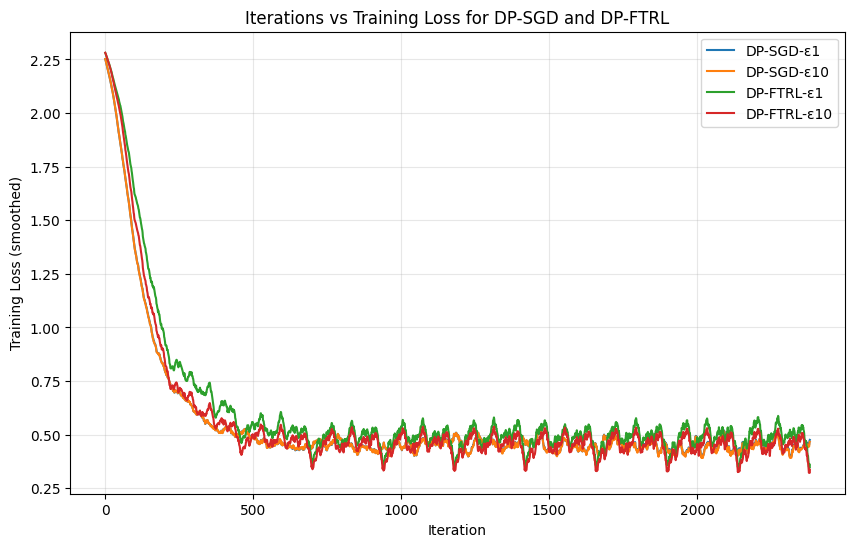

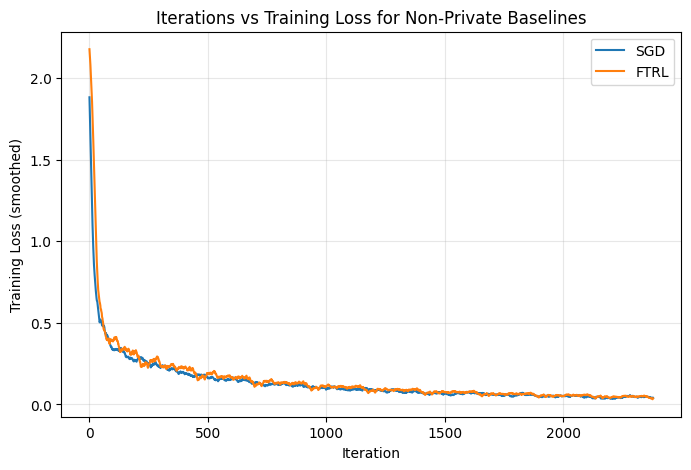

In [22]:
plt.figure(figsize=(10, 6))

for key, res in results.items():
    if res.method in ["DP-SGD", "DP-FTRL"]:
        smoothed = moving_average(res.iteration_losses, window=20)
        plt.plot(smoothed, label=key)

plt.xlabel("Iteration")
plt.ylabel("Training Loss (smoothed)")
plt.title("Iterations vs Training Loss for DP-SGD and DP-FTRL")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))

for key in ["SGD", "FTRL"]:
    res = results[key]
    smoothed = moving_average(res.iteration_losses, window=20)
    plt.plot(smoothed, label=key)

plt.xlabel("Iteration")
plt.ylabel("Training Loss (smoothed)")
plt.title("Iterations vs Training Loss for Non-Private Baselines")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Plot 2: Epsilon Spent vs Epochs

Only the private optimizers have a privacy budget curve.

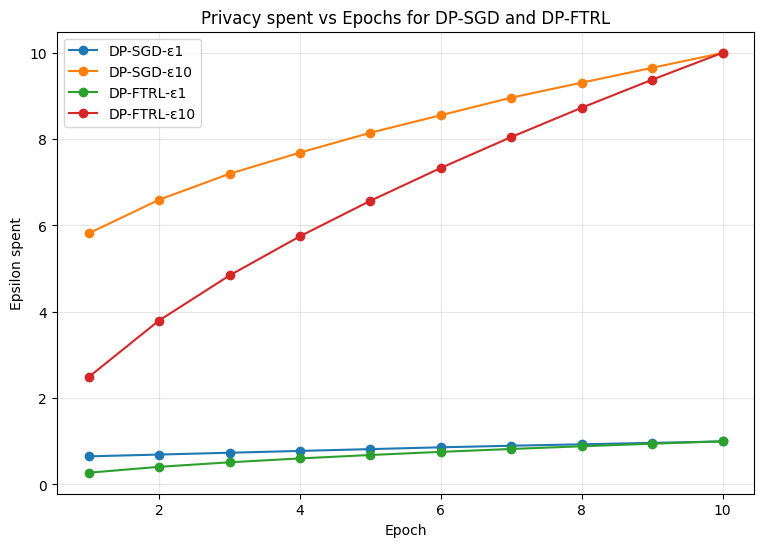

In [23]:
epochs_axis = np.arange(1, EPOCHS + 1)

plt.figure(figsize=(9, 6))

for key, res in results.items():
    if res.method in ["DP-SGD", "DP-FTRL"]:
        plt.plot(epochs_axis, res.epsilons, marker="o", label=key)

plt.xlabel("Epoch")
plt.ylabel("Epsilon spent")
plt.title("Privacy spent vs Epochs for DP-SGD and DP-FTRL")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Plot 3: Target Epsilon vs Test Accuracy

We compare:
- DP-SGD
- DP-FTRL

and also show the non-private baselines:
- SGD
- FTRL

For Plot 3, the private methods are compared directly across target privacy budgets $\epsilon \in \{1,10\}$.  
The non-private SGD and FTRL accuracies are shown as horizontal reference lines since they do not correspond to a finite target privacy budget.

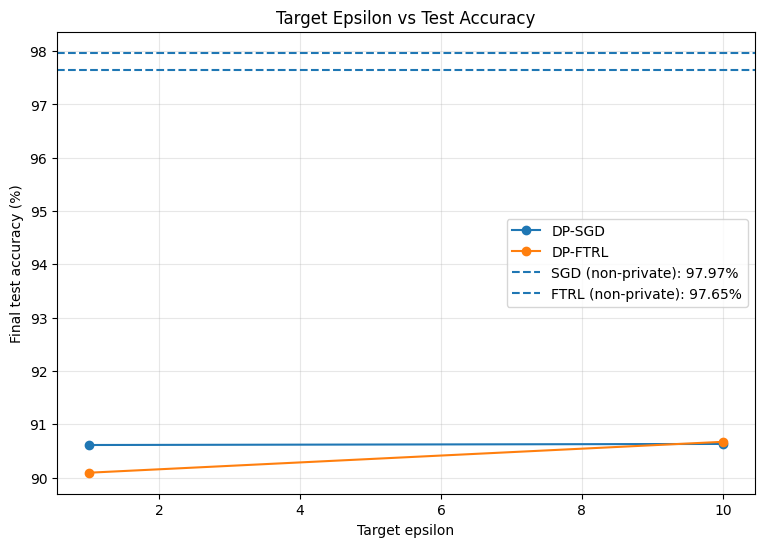

In [24]:
dp_sgd_plot = summary_df[summary_df["method"] == "DP-SGD"].sort_values("target_epsilon")
dp_ftrl_plot = summary_df[summary_df["method"] == "DP-FTRL"].sort_values("target_epsilon")

sgd_acc = summary_df.loc[summary_df["method"] == "SGD", "final_test_accuracy"].iloc[0]
ftrl_acc = summary_df.loc[summary_df["method"] == "FTRL", "final_test_accuracy"].iloc[0]

plt.figure(figsize=(9, 6))

plt.plot(
    dp_sgd_plot["target_epsilon"],
    dp_sgd_plot["final_test_accuracy"],
    marker="o",
    label="DP-SGD",
)

plt.plot(
    dp_ftrl_plot["target_epsilon"],
    dp_ftrl_plot["final_test_accuracy"],
    marker="o",
    label="DP-FTRL",
)

plt.axhline(y=sgd_acc, linestyle="--", label=f"SGD (non-private): {sgd_acc:.2f}%")
plt.axhline(y=ftrl_acc, linestyle="--", label=f"FTRL (non-private): {ftrl_acc:.2f}%")

plt.xlabel("Target epsilon")
plt.ylabel("Final test accuracy (%)")
plt.title("Target Epsilon vs Test Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Final Observations

1. **SGD vs DP-SGD**  
   As the target privacy budget becomes larger $(larger (\epsilon))$, DP-SGD usually needs less noise and therefore tends to achieve better utility.

2. **FTRL vs DP-FTRL**  
   DP-FTRL uses tree-aggregated Gaussian noise and FTRL-style updates. Depending on the privacy regime, it can behave differently from DP-SGD and may provide competitive utility.

3. **Epsilon curves**  
   The $(\epsilon)$-spent curves for the private optimizers show how privacy loss accumulates over epochs.

4. **Main takeaway**  
   This experiment compares two private optimization strategies:
   - DP-SGD with the Opacus RDP accountant
   - DP-FTRL with tree-aggregation and the repository privacy computation

   The final comparison should be made using:
   - training-loss behavior
   - privacy-spending curves
   - final test accuracy at the same target privacy budget

## Conclusion

### For DP-FTRL, we used a fixed data order across epochs (i.e., no reshuffling), since the privacy accounting used for the DP-FTRL implementation assumes the same batch order is maintained across epochs. SGD and DP-SGD were still trained with shuffled mini-batches.

In this notebook, we compared:

- **SGD**
- **FTRL**
- **DP-SGD**
- **DP-FTRL**

on MNIST using a feed-forward neural network.

For the private methods, we evaluated the target privacy budgets

$$
\epsilon \in \{1, 10\}, \qquad \delta = 10^{-5}.
$$

We reported the three required plots:

1. **Number of Iterations (Epoch × Batches) vs Training Loss**
2. **$\epsilon$ spent vs Epochs**
3. **Target Epsilon vs Test Accuracy**

### Main observations

- The non-private methods achieve the best utility, as expected.
- Both DP-SGD and DP-FTRL incur a utility drop due to the privacy mechanism.
- The privacy budget spent across epochs increases steadily for both private methods.
- The final comparison across target $\epsilon$ values shows how privacy level affects test accuracy under the two private optimization strategies.

### Reproducibility note

The DP-FTRL part of the implementation depends on the helper files:

- `dpftrl_optimizers.py`
- `dpftrl_noise.py`
- `dpftrl_privacy.py`

These files should be included in the submitted codebase so that the experiment can be reproduced exactly.